In [103]:
#Config and connection testing
from google.cloud import bigquery
from src.config import settings

# For EDA, Data prepareation, Data visulisation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#For network plot
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
from collections import Counter


In [76]:
#Create Base DF
client = bigquery.Client(project=settings.project_id)
df = client.query(f"""
SELECT distinct src.*,dp.product_name,dc.customer_id,dp.product_category from `jr-data-training.dbt_medallion_dev_gold.fact_order_items` src left join `jr-data-training.dbt_medallion_dev_gold.dim_products` dp on src.product_key = dp.product_key
left join `jr-data-training.dbt_medallion_dev_gold.dim_customers` dc on src.customer_key = dc.customer_key
where product_category is not null
""").to_dataframe()

C:\cafe-analysis\data-training\.venv\Lib\site-packages\google\auth\_default.py:108: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)
C:\cafe-analysis\data-training\.venv\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


### Data Understanding
- To understand dataset shape,type

In [ ]:
df.head()

,order_id,order_item_id,order_date,order_time,order_total_price,order_gst,order_surcharge,order_display_price,order_display_gst,cart_size,cart_order_time,customer_key,product_key,product_name,customer_id,product_category
0,3424,1,2019-07-26,08:43:16,470,42.727272727,0,4.70,0.43,1,ASAP,a5bfc9e07964f8dddeb95fc584cd965d,52248cff6575d705834dee4e4a5b4346,Latte,37,Hot Drinks
1,3434,1,2019-07-28,10:28:52,4230,384.545454545,0,42.30,3.85,6,1564275600,1ff1de774005f8da13f42943881c655f,605a580fc52f5e41734804d3c050ace9,Chai Latte,24,Hot Drinks
2,3440,1,2019-08-02,11:58:43,1610,146.363636364,0,16.10,1.46,4,ASAP,17e62166fc8586dfa4d1bc0e1742c08b,26dc8c033c0b09718b3d31998bc61c8e,Flat White,43,Hot Drinks
3,3520,1,2019-08-27,11:31:21,890,80.909090909,0,8.90,0.81,2,ASAP,03afdbd66e7929b125f8597834fa83a4,26dc8c033c0b09718b3d31998bc61c8e,Flat White,63,Hot Drinks
4,3531,1,2019-08-31,08:24:14,1190,108.181818182,0,11.90,1.08,3,ASAP,d3d9446802a44259755d38e6d163e820,a14814a6ca23686a5aaab7219e07a58c,Cappuccino,10,Hot Drinks


In [79]:
#Null display_price,gstsurcharge exist in source data, example order_id = 3286
df.isnull().sum()

order_id                0
order_item_id           0
order_date              0
order_time              0
order_total_price       0
order_gst               0
order_surcharge        48
order_display_price    36
order_display_gst      36
cart_size               0
cart_order_time         0
customer_key            0
product_key             0
product_name            0
customer_id             0
product_category        0
dtype: int64

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81486 entries, 0 to 81485
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   order_id             81486 non-null  Int64 
 1   order_item_id        81486 non-null  Int64 
 2   order_date           81486 non-null  dbdate
 3   order_time           81486 non-null  dbtime
 4   order_total_price    81486 non-null  Int64 
 5   order_gst            81486 non-null  object
 6   order_surcharge      81438 non-null  Int64 
 7   order_display_price  81450 non-null  object
 8   order_display_gst    81450 non-null  object
 9   cart_size            81486 non-null  object
 10  cart_order_time      81486 non-null  object
 11  customer_key         81486 non-null  object
 12  product_key          81486 non-null  object
 13  product_name         81486 non-null  object
 14  customer_id          81486 non-null  Int64 
 15  product_category     81486 non-null  object
dtypes: I

## Variable visulisation

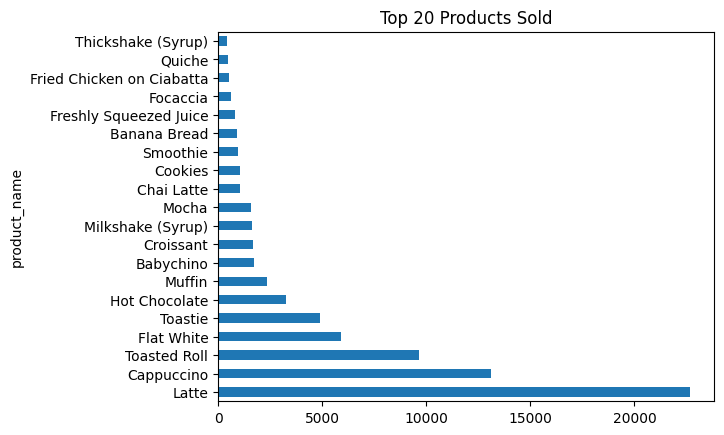

In [ ]:
#Sales qty by top 20 products
top_products = (
    df.groupby('product_name')
      .size()
      .sort_values(ascending=False)
      .head(20)
).plot(kind = 'barh')
plt.title("Top 20 Products Sold")
plt.show()


In [128]:
basket_products[basket_products.apply(lambda x: len(x)> 2)]

order_id
3287                          [Latte, Affogato, Babychino]
3293                 [Espresso, Flat White, Hot Chocolate]
3295             [Chai Latte, Affogato, Cappuccino, Mocha]
3316     [Croissant, Freshly Squeezed Juice, Toastie, T...
3317     [Toastie, Toastie, Piccolo, Croissant, Croissa...
                               ...                        
40603    [Milkshake (Syrup), Toastie, Toastie, Chai Latte]
40605    [Belgian Waffles, Magic, Acai Smoothie bowl (VO)]
40611                              [Mocha, Muffin, Muffin]
40624                        [Croissant, Croissant, Latte]
40643                [Coffee Frappe, Coffee Frappe, Latte]
Name: product_name, Length: 11553, dtype: object

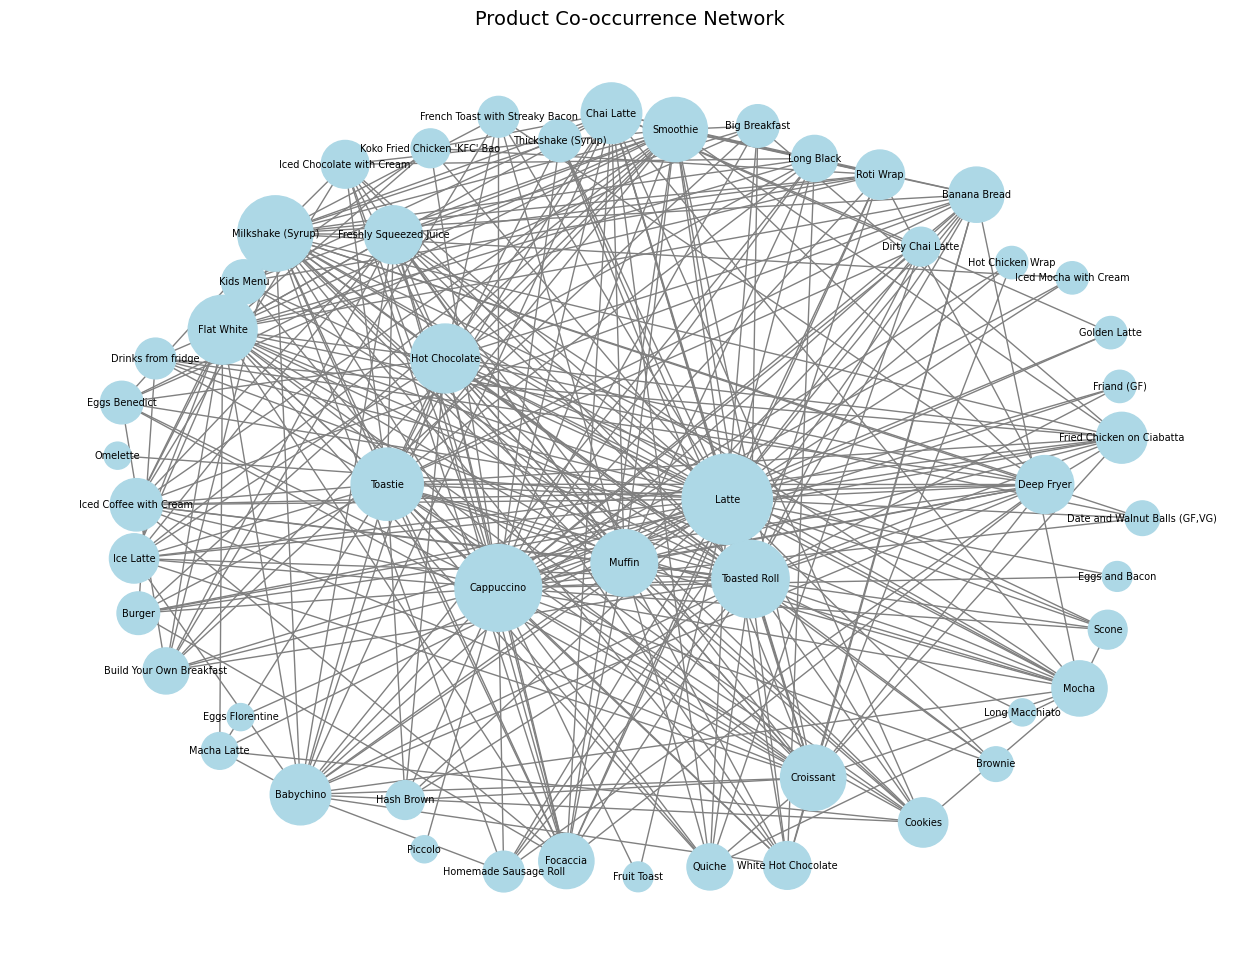

In [136]:
basket_products = df.groupby('order_id')['product_name'].apply(list) #Aggregate sold product by order id to list


#Visulised order id with more then 1  item 
#basket_products[basket_products.apply(lambda x: len(x) > 1)]


pair_counts = Counter()
for row in basket_products:
    # Use set(row) to remove duplicates
    for combo in combinations(set(row), 2):
        pair_counts[combo] += 1

pair_df = pd.DataFrame(
    [(a, b, c) for (a, b), c in pair_counts.items()],
    columns=['prod_A', 'prod_B', 'count']
)


#Remove weak association
MIN_EDGE_WEIGHT = 10
pair_df = pair_df[pair_df['count'] >= MIN_EDGE_WEIGHT]


#Creating Network graph
G = nx.Graph()

for _, row in pair_df.iterrows():
    G.add_edge(row['prod_A'], row['prod_B'], weight=row['count'])

G.remove_nodes_from(list(nx.isolates(G))) #Remove node with no conection


#Adjust layout 
pos = nx.spring_layout(
    G,
    k=15.5,                 
    iterations=80,        
    seed=42
)

plt.figure(figsize=(16, 12))

# Scale node size based on number of connections
node_sizes = [300 + 80 * G.degree(n) for n in G.nodes()]

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    node_size=node_sizes,
    node_color="lightblue",
    edge_color="gray",
    font_size=7,
)

plt.title("Product Co-occurrence Network", fontsize=14)
plt.axis("off")
plt.show()


In [ ]:
#POC Product Recommander

In [137]:

user_features = df.groupby('customer_id').agg(
    total_orders=('order_id', 'nunique'),
    total_items=('order_item_id', 'count'),
    total_spent=('order_total_price', 'sum'),
    avg_order_value=('order_total_price', 'mean'),
    unique_products=('product_key', 'nunique'),
    last_order_date=('order_date', 'max')
).reset_index()

In [140]:
product_features = df.groupby('product_key').agg(
    product_name=('product_name', 'first'),
    product_category=('product_category', 'first'),
    total_sales=('order_total_price', 'sum'),
    total_quantity=('order_item_id', 'count'),
    unique_customers=('customer_id', 'nunique')
).reset_index()
product_features

,product_key,product_name,product_category,total_sales,total_quantity,unique_customers
0,00d93c730ce8d6eaeb68a0ff7169fd64,Flat White,Hot Drinks,902491,615,114
1,013e43b1f857d66050f376ecb7afd235,(Entree) Pasta,Kitchen,7330,2,2
2,01fbd873a21a56dbd8cfeeabf4a9da7f,Mocha,Hot Drinks,289260,177,61
3,03d8fa4e0a5873b05317634b0b917562,Chicken & Mushroom Crepe,Kitchen,96650,6,3
4,065aafd5ae5cc7ea7eca37b0dc3b683a,Magic,Hot Drinks,29830,23,6
...,...,...,...,...,...,...
250,fd025b79fbd5afb5fb7a1b97ef921fb1,Thickshake (Syrup),Cold Drinks,357160,114,59
251,fdaefdc77cec26cb64f647f0d6cd603b,Burger,Kitchen,243690,61,33
252,fe979a5d58319803fb21e75b0896d6f3,Banana Bread,Cold Drinks,1199600,698,80
253,ff027e0dc3b7bee9fc1490d67792c2ae,Plain Toast,Kitchen,10830,10,1


In [141]:
interaction_features = df.groupby(['customer_id', 'product_key']).agg(
    times_purchased=('order_id', 'count'),
    total_spent=('order_total_price', 'sum'),
    last_purchase_date=('order_date', 'max')
).reset_index()

# Recency of last purchase
interaction_features['recency_days'] = (pd.to_datetime('2025-11-16') - pd.to_datetime(interaction_features['last_purchase_date'])).dt.days


In [143]:
import numpy as np

# All products
all_products = df['product_key'].unique()

neg_samples = []
for cust in df['customer_id'].unique():
    purchased = df[df['customer_id']==cust]['product_key'].unique()
    not_purchased = np.setdiff1d(all_products, purchased)
    for p in not_purchased[:5]:  # sample 5 negatives per user
        neg_samples.append({'customer_id': cust, 'product_key': p, 'times_purchased': 0, 'total_spent': 0, 'recency_days': 999})
neg_df = pd.DataFrame(neg_samples)

# Combine with positive interactions
train_df = pd.concat([interaction_features, neg_df], ignore_index=True)


In [144]:
train_df

,customer_id,product_key,times_purchased,total_spent,last_purchase_date,recency_days
0,4,3d1bbcb7fc862c66983fcf82daf5250d,2,700,2019-05-05,2387
1,4,ceb3975d43ebc8849747525ded02f2be,1,350,2019-05-05,2387
2,5,00d93c730ce8d6eaeb68a0ff7169fd64,11,22930,2020-03-06,2081
3,5,01fbd873a21a56dbd8cfeeabf4a9da7f,4,3420,2019-05-12,2380
4,5,03d8fa4e0a5873b05317634b0b917562,4,87260,2020-03-20,2067
...,...,...,...,...,...,...
17586,1680,00d93c730ce8d6eaeb68a0ff7169fd64,0,0,NaT,999
17587,1680,013e43b1f857d66050f376ecb7afd235,0,0,NaT,999
17588,1680,01fbd873a21a56dbd8cfeeabf4a9da7f,0,0,NaT,999
17589,1680,03d8fa4e0a5873b05317634b0b917562,0,0,NaT,999


In [145]:
train_df = train_df.merge(user_features, on='customer_id', how='left')
train_df = train_df.merge(product_features, on='product_key', how='left')


In [149]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17591 entries, 0 to 17590
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         17591 non-null  Int64  
 1   product_key         17591 non-null  object 
 2   times_purchased     17591 non-null  Int64  
 3   total_spent_x       17591 non-null  Int64  
 4   last_purchase_date  9056 non-null   dbdate 
 5   recency_days        17591 non-null  int64  
 6   total_orders        17591 non-null  int64  
 7   total_items         17591 non-null  Int64  
 8   total_spent_y       17591 non-null  Int64  
 9   avg_order_value     17591 non-null  Float64
 10  unique_products     17591 non-null  int64  
 11  last_order_date     17591 non-null  dbdate 
 12  product_name        17591 non-null  object 
 13  product_category    17591 non-null  object 
 14  total_sales         17591 non-null  Int64  
 15  total_quantity      17591 non-null  Int64  
 16  uniq

In [150]:
import xgboost as xgb

# Features and label
features = [col for col in train_df.columns if col not in ['customer_id','product_key','last_purchase_date','product_name','product_category']]
# Drop datetime columns
X = train_df.drop(columns=[
    'customer_id', 'product_key', 
    'last_purchase_date', 'last_order_date', 
    'product_name', 'product_category'
])
y = (train_df['times_purchased'] > 0).astype(int)

# Grouping per customer (required for ranking)
group = train_df.groupby('customer_id').size().to_numpy()

dtrain = xgb.DMatrix(X, label=y)


In [155]:
y

0        1
1        1
2        1
3        1
4        1
        ..
17586    0
17587    0
17588    0
17589    0
17590    0
Name: times_purchased, Length: 17591, dtype: int64

In [157]:
group

array([  7, 101,  15, ...,   6,   6,   7], shape=(1707,))

In [158]:
import numpy as np

# Unique customers
customers = train_df['customer_id'].unique()
np.random.seed(42)
np.random.shuffle(customers)

# Split 80% train, 20% val
train_customers = customers[:int(0.8 * len(customers))]
val_customers = customers[int(0.8 * len(customers)):]

# Create train/val sets based on customers
X_train = X[train_df['customer_id'].isin(train_customers)]
y_train = y[train_df['customer_id'].isin(train_customers)]
X_val   = X[train_df['customer_id'].isin(val_customers)]
y_val   = y[train_df['customer_id'].isin(val_customers)]

# Recompute group for train/val
group_train = X_train.groupby(train_df.loc[X_train.index, 'customer_id']).size().to_numpy()
group_val   = X_val.groupby(train_df.loc[X_val.index, 'customer_id']).size().to_numpy()


C:\Users\laaro\AppData\Local\Temp\ipykernel_78244\3525990107.py:6: UserWarning: you are shuffling a 'IntegerArray' object which is not a subclass of 'Sequence'; `shuffle` is not guaranteed to behave correctly. E.g., non-numpy array/tensor objects with view semantics may contain duplicates after shuffling.
  np.random.shuffle(customers)


In [168]:
import xgboost as xgb
import numpy as np

# Ensure last_purchase_date / order_date are numeric or removed
#X_train = X_train.drop(columns=['last_purchase_date', 'order_date'])
#X_val   = X_val.drop(columns=['last_purchase_date', 'order_date'])

ranker = xgb.XGBRanker(
    objective='rank:pairwise',
    learning_rate=0.1,
    max_depth=6
)

ranker.fit(
    X_train, y_train,
    group=group_train,
    eval_set=[(X_val, y_val)],
    eval_group=[group_val],
    verbose=True
)


[0]	validation_0-ndcg@32:1.00000
[1]	validation_0-ndcg@32:1.00000
[2]	validation_0-ndcg@32:1.00000
[3]	validation_0-ndcg@32:1.00000
[4]	validation_0-ndcg@32:1.00000
[5]	validation_0-ndcg@32:1.00000
[6]	validation_0-ndcg@32:1.00000
[7]	validation_0-ndcg@32:1.00000
[8]	validation_0-ndcg@32:1.00000
[9]	validation_0-ndcg@32:1.00000
[10]	validation_0-ndcg@32:1.00000
[11]	validation_0-ndcg@32:1.00000
[12]	validation_0-ndcg@32:1.00000
[13]	validation_0-ndcg@32:1.00000
[14]	validation_0-ndcg@32:1.00000
[15]	validation_0-ndcg@32:1.00000
[16]	validation_0-ndcg@32:1.00000
[17]	validation_0-ndcg@32:1.00000
[18]	validation_0-ndcg@32:1.00000
[19]	validation_0-ndcg@32:1.00000
[20]	validation_0-ndcg@32:1.00000
[21]	validation_0-ndcg@32:1.00000
[22]	validation_0-ndcg@32:1.00000
[23]	validation_0-ndcg@32:1.00000
[24]	validation_0-ndcg@32:1.00000
[25]	validation_0-ndcg@32:1.00000
[26]	validation_0-ndcg@32:1.00000
[27]	validation_0-ndcg@32:1.00000
[28]	validation_0-ndcg@32:1.00000
[29]	validation_0-ndcg@3

,objective,'rank:pairwise'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [175]:
# Predict ranking scores for validation set
y_val_pred = ranker.predict(X_val)

In [182]:
import pandas as pd
import numpy as np

# Example: New customer wants to see 5 candidate products
X_new = pd.DataFrame({
    'product_key': ['p1', 'p2', 'p3', 'p4', 'p5'],
    'product_price': [4.5, 5.0, 6.0, 3.5, 7.0],
    'product_category': ['Hot Drinks', 'Hot Drinks', 'Cold Drinks', 'Bakery', 'Hot Drinks'],
    'days_since_last_purchase': [10, 5, 20, 7, 15],
    'total_orders': [25, 30, 10, 15, 5],
    'total_items': [50, 60, 20, 25, 10],
    'total_spent': [200, 250, 100, 120, 50],
    'avg_order_value': [8.0, 8.33, 5.0, 8.0, 10.0],
    'unique_products': [5, 6, 3, 4, 2],
    'total_sales': [5000, 6000, 2000, 2500, 1000],
    'total_quantity': [100, 120, 40, 50, 20],
    'unique_customers': [80, 90, 40, 50, 15]
})

# Convert object columns to category
X_new['product_key'] = X_new['product_key'].astype('category')
X_new['product_category'] = X_new['product_category'].astype('category')

# If using XGB >=1.7, enable categorical handling
y_new_pred = ranker.predict(X_new)

X_new['pred_score'] = y_new_pred
X_new_sorted = X_new.sort_values('pred_score', ascending=False)
print(X_new_sorted)


# Encode categorical column if needed (example: one-hot encoding)
X_new = pd.get_dummies(X_new, columns=['product_category'], drop_first=True)

# Group array for XGBRanker
group_new = [len(X_new)]  # all 5 items belong to the same customer

# Example of predicting rank
y_new_pred = ranker.predict(X_new)
X_new['pred_score'] = y_new_pred

# Sort by predicted score
X_new_sorted = X_new.sort_values('pred_score', ascending=False)
print(X_new_sorted)


ValueError: feature_names mismatch: ['times_purchased', 'total_spent_x', 'recency_days', 'total_orders', 'total_items', 'total_spent_y', 'avg_order_value', 'unique_products', 'total_sales', 'total_quantity', 'unique_customers'] ['product_key', 'product_price', 'product_category', 'days_since_last_purchase', 'total_orders', 'total_items', 'total_spent', 'avg_order_value', 'unique_products', 'total_sales', 'total_quantity', 'unique_customers']
expected total_spent_y, total_spent_x, recency_days, times_purchased in input data
training data did not have the following fields: total_spent, product_price, product_key, product_category, days_since_last_purchase

In [183]:
# Construct X_new with the same column names as X_train
X_new = pd.DataFrame({
    'times_purchased': [5, 3, 2, 7, 1],
    'total_spent_x': [200, 150, 100, 300, 50],
    'recency_days': [10, 5, 20, 7, 15],
    'total_orders': [25, 20, 10, 30, 5],
    'total_items': [50, 40, 20, 60, 10],
    'total_spent_y': [220, 160, 110, 310, 55],
    'avg_order_value': [8.0, 7.5, 5.0, 10.0, 11.0],
    'unique_products': [5, 4, 3, 6, 2],
    'total_sales': [5000, 4000, 2000, 6000, 1000],
    'total_quantity': [100, 80, 40, 120, 20],
    'unique_customers': [80, 60, 40, 100, 15]
})

# Group array for XGBRanker
group_new = [len(X_new)]  # all 5 items belong to the same customer

# Predict ranking scores
y_new_pred = ranker.predict(X_new)
X_new['pred_score'] = y_new_pred

# Sort by predicted score
X_new_sorted = X_new.sort_values('pred_score', ascending=False)
print(X_new_sorted)


   times_purchased  total_spent_x  recency_days  total_orders  total_items  \
0                5            200            10            25           50   
1                3            150             5            20           40   
2                2            100            20            10           20   
3                7            300             7            30           60   
4                1             50            15             5           10   

   total_spent_y  avg_order_value  unique_products  total_sales  \
0            220              8.0                5         5000   
1            160              7.5                4         4000   
2            110              5.0                3         2000   
3            310             10.0                6         6000   
4             55             11.0                2         1000   

   total_quantity  unique_customers  pred_score  
0             100                80    1.017069  
1              80           

In [184]:
X_new_sorted

,times_purchased,total_spent_x,recency_days,total_orders,total_items,total_spent_y,avg_order_value,unique_products,total_sales,total_quantity,unique_customers,pred_score
0,5,200,10,25,50,220,8.0,5,5000,100,80,1.017069
1,3,150,5,20,40,160,7.5,4,4000,80,60,1.017069
2,2,100,20,10,20,110,5.0,3,2000,40,40,1.017069
3,7,300,7,30,60,310,10.0,6,6000,120,100,1.017069
4,1,50,15,5,10,55,11.0,2,1000,20,15,1.017069
